# Домашнее задание "Продвинутая оптимизация".

### Задание

При фиксированном `seed=42` поэкспериментируйте с параметрами алгоритма [differential_evolution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.differential_evolution.html): strategy, popsize, mutation.

Постройте графики количества итераций (`nit`) оптимизации [функции ackley](https://en.wikipedia.org/wiki/Ackley_function) от значения параметра. 

Подробнее о результате выдачи [тут](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.OptimizeResult.html).

In [13]:
import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

%matplotlib inline

In [14]:
def ackley(x):
    arg1 = -0.2 * np.sqrt(0.5 * (x[0] ** 2 + x[1] ** 2))
    arg2 = 0.5 * (np.cos(2. * np.pi * x[0]) + np.cos(2. * np.pi * x[1]))
    return -20. * np.exp(arg1) - np.exp(arg2) + 20. + np.e

bounds = [(-10, 10), (-10, 10)]

result = differential_evolution(ackley, bounds, seed=42)
result

 message: Optimization terminated successfully.
 success: True
     fun: 4.440892098500626e-16
       x: [ 0.000e+00  0.000e+00]
     nit: 90
    nfev: 2793

In [23]:
strategies = ['best1bin', 'rand1bin', 'best1exp', 'rand2bin', 'currenttobest1bin']
popsizes = [5, 10, 20]
mutations = [0.5, 0.7, (0.7, 1.5)]

results = []

for strategy in strategies:
    for popsize in popsizes:
        for mutation in mutations:
            res = differential_evolution(
                ackley,
                bounds,
                strategy=strategy,
                popsize=popsize,
                mutation=mutation,
                seed=42
            )
            results.append((strategy, popsize, mutation, res.nit))




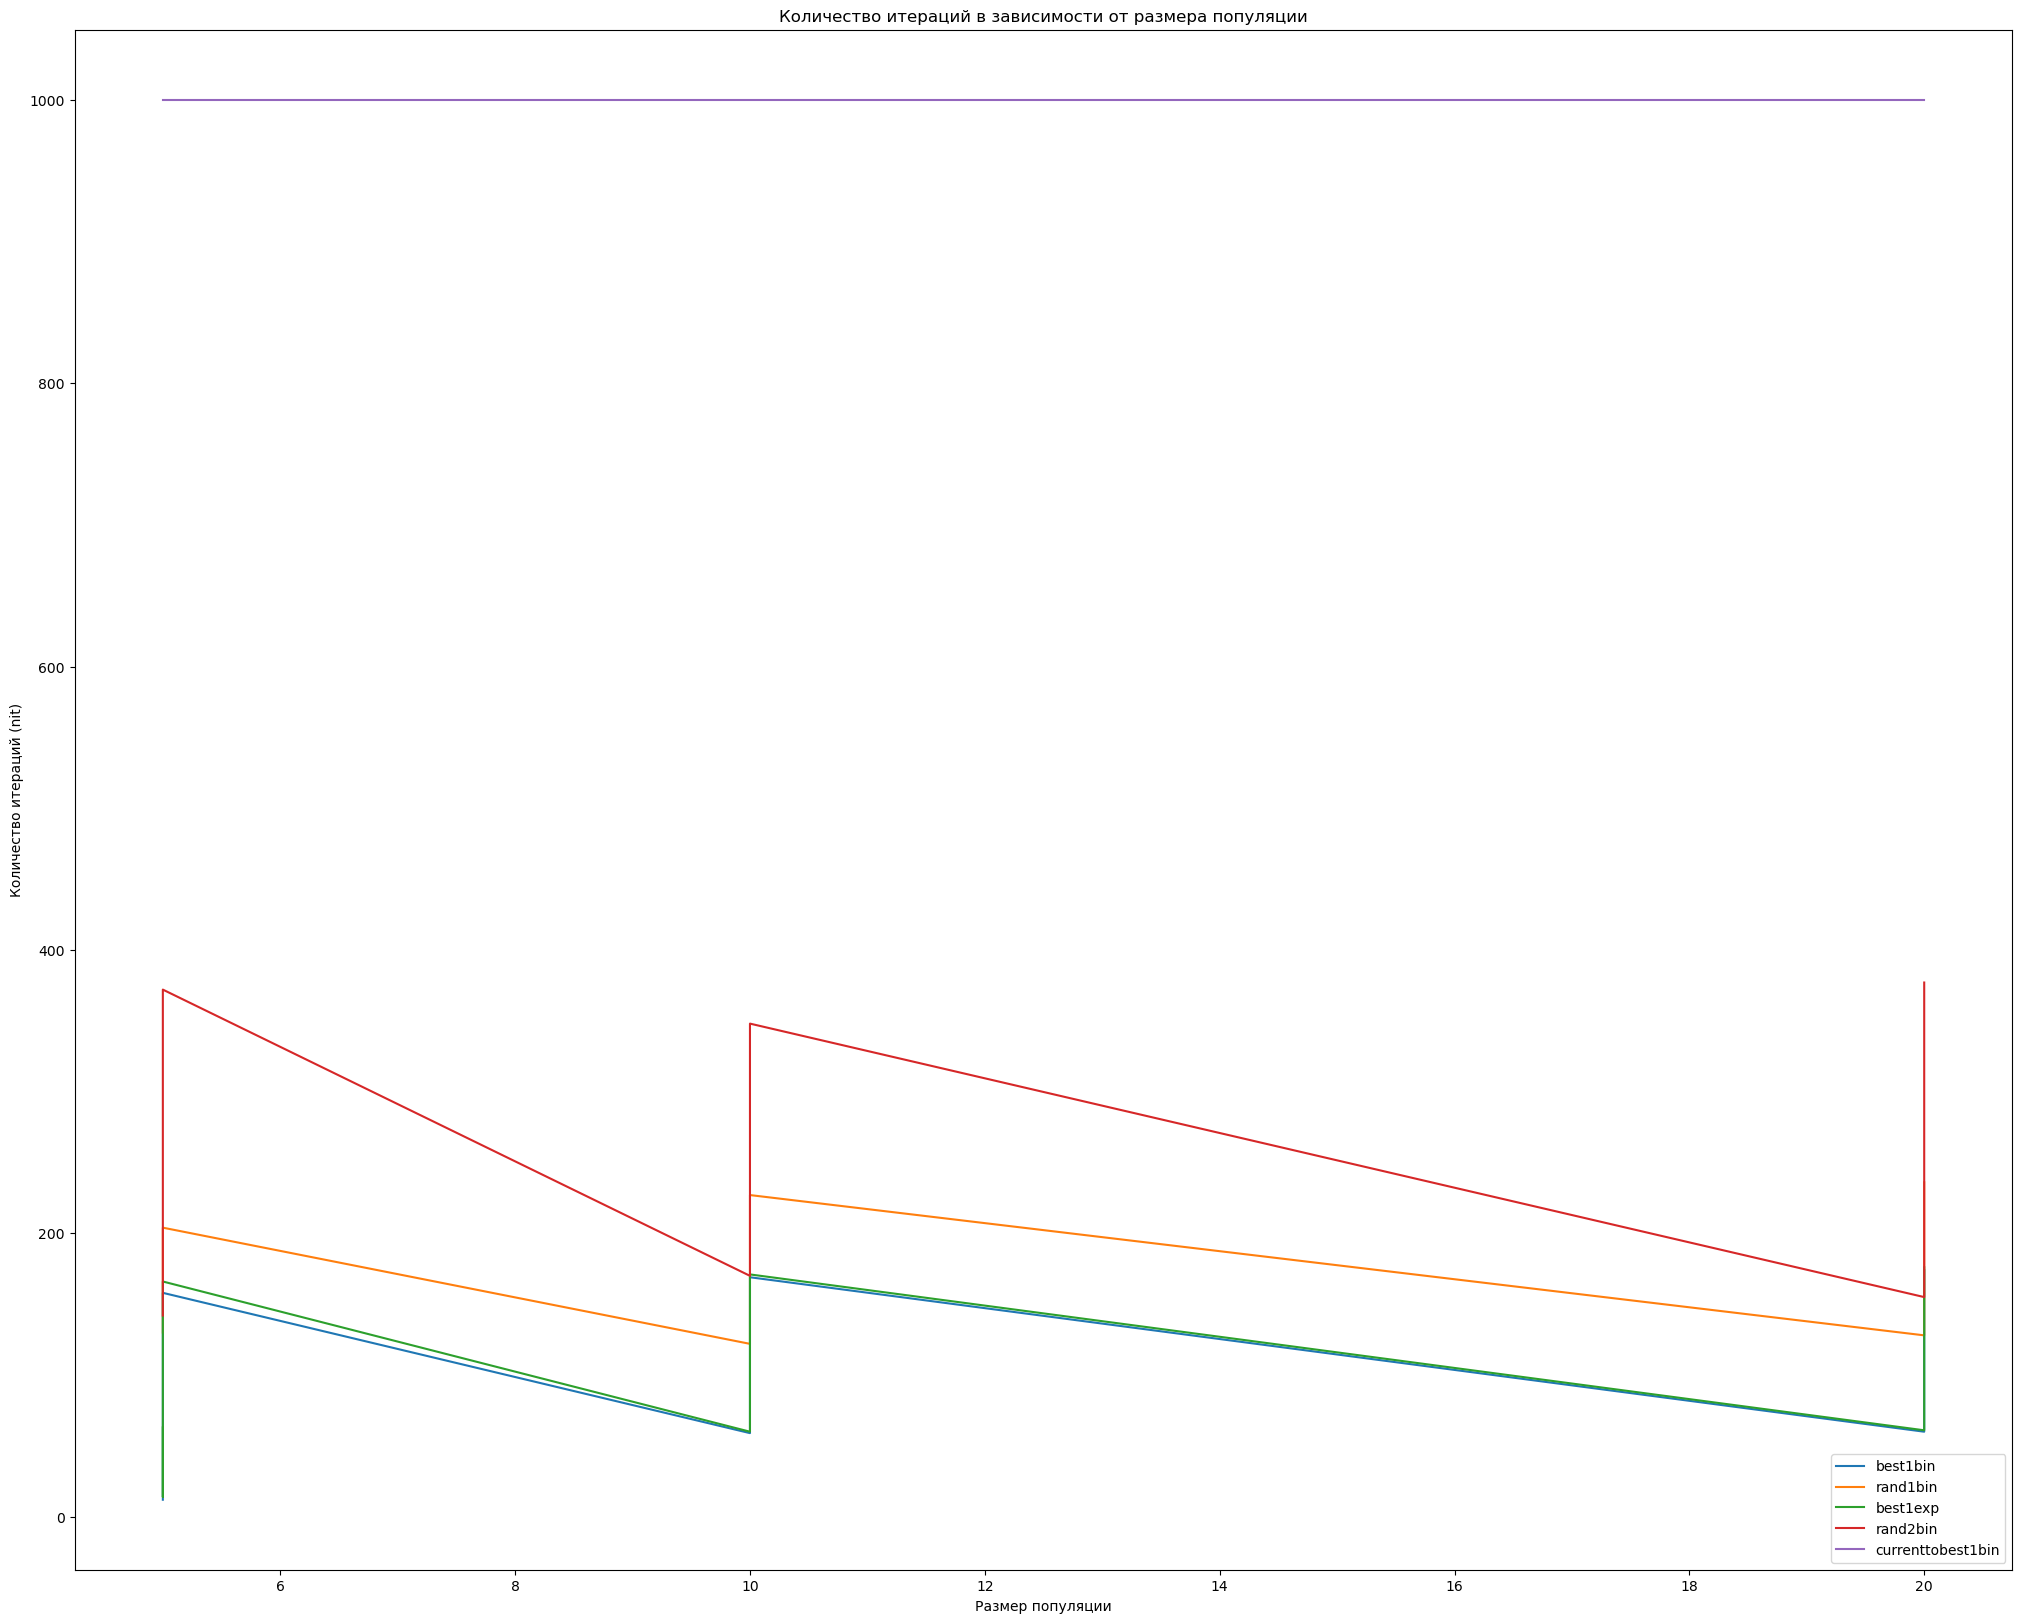

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(25, 20))

for strategy in strategies:
    filtered_results = [r for r in results if r[0] == strategy]
    popsizes = [r[1] for r in filtered_results]
    nits = [r[3] for r in filtered_results]

    plt.plot(popsizes, nits, label=strategy)

plt.xlabel('Размер популяции')
plt.ylabel('Количество итераций (nit)')
plt.title('Количество итераций в зависимости от размера популяции')
plt.legend()
plt.show()

### Дополнительное задание


Поэкспериментируйте с параметрами и оптимизацией через [minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html):

In [33]:
from scipy.optimize import minimize

x0 = [0,0]

result_m = minimize(ackley, x0,  method='Nelder-Mead')
result_m

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 4.440892098500626e-16
             x: [ 0.000e+00  0.000e+00]
           nit: 8
          nfev: 17
 final_simplex: (array([[ 0.000e+00,  0.000e+00],
                       [-1.607e-05, -8.453e-06],
                       [-1.404e-06, -3.113e-05]]), array([ 4.441e-16,  5.136e-05,  8.816e-05]))

In [45]:
### YOUR CODE HERE
methods = [
    'Nelder-Mead',
    'Powell',
    'CG',
    'BFGS',
    'Newton-CG',
    'L-BFGS-B',
    'TNC',
    'COBYLA',
    'COBYQA',
    'SLSQP',
    'trust-constr',
    'dogleg',
    'trust-ncg',
    'trust-exact',
    'trust-krylov'
]

good_methods = {}
for method in methods:
    try:
        result = minimize(ackley, x0, method=method)
        print(f"Метод: {method}")
        print(result)
        print("\n")
        good_methods[method] = result
    except Exception as e:
        print(f"Ошибка при использовании метода {method}: {e}")



Метод: Nelder-Mead
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.574451924990758
             x: [ 9.685e-01  9.685e-01]
           nit: 24
          nfev: 47
 final_simplex: (array([[ 9.685e-01,  9.685e-01],
                       [ 9.684e-01,  9.684e-01],
                       [ 9.685e-01,  9.686e-01]]), array([ 3.574e+00,  3.574e+00,  3.574e+00]))


Метод: Powell
 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 3.5744518773309406
       x: [ 9.685e-01  9.685e-01]
     nit: 2
   direc: [[ 1.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00]]
    nfev: 53


Метод: CG
 message: Desired error not necessarily achieved due to precision loss.
 success: False
  status: 2
     fun: 2.2288034973172444e-08
       x: [-5.572e-09 -5.572e-09]
     nit: 1
     jac: [ 5.669e-01  5.669e-01]
    nfev: 228
    njev: 72


Метод: BFGS
  message: Desired error not necessarily achieved due to precisio

In [46]:
for method, result in good_methods.items():
    print(f"Метод: {method}")
    print(result)
    print("\n")


Метод: Nelder-Mead
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.574451924990758
             x: [ 9.685e-01  9.685e-01]
           nit: 24
          nfev: 47
 final_simplex: (array([[ 9.685e-01,  9.685e-01],
                       [ 9.684e-01,  9.684e-01],
                       [ 9.685e-01,  9.686e-01]]), array([ 3.574e+00,  3.574e+00,  3.574e+00]))


Метод: Powell
 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 3.5744518773309406
       x: [ 9.685e-01  9.685e-01]
     nit: 2
   direc: [[ 1.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00]]
    nfev: 53


Метод: CG
 message: Desired error not necessarily achieved due to precision loss.
 success: False
  status: 2
     fun: 2.2288034973172444e-08
       x: [-5.572e-09 -5.572e-09]
     nit: 1
     jac: [ 5.669e-01  5.669e-01]
    nfev: 228
    njev: 72


Метод: BFGS
  message: Desired error not necessarily achieved due to precisio

Вы также можете поэкспериментировать с [другими методами оптимизации](https://habr.com/ru/company/prequel/blog/568496/), но это не обязательно для зачета.
